<a href="https://colab.research.google.com/github/Joydas2003/Electrical-Load-Forcasting-Ml/blob/master/Machine%20Learning%20Based%20short%20term%20Electrical%20Load%20Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')
pgcb_df=pd.read_csv( "/content/drive/MyDrive/Load Forcasting/PGCB_date_power_demand.csv")
nasa_df=pd.read_csv("/content/drive/MyDrive/Load Forcasting/Hourly_Temp_Humidity (2).csv")
from IPython.display import display

display(pgcb_df)
display(nasa_df)

Mounted at /content/drive


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks
0,4/19/2015 22:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,4/19/2015 21:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,4/19/2015 19:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,4/19/2015 18:30,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,4/19/2015 18:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,6/17/2025 4:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN
92646,6/17/2025 3:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN
92647,6/17/2025 2:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN
92648,6/17/2025 1:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN


,datetime,Temperature_C,Humidity_%
0,2015-01-19 00:00:00,13.79,66.79
1,2015-01-19 01:00:00,13.25,69.37
2,2015-01-19 02:00:00,12.73,72.19
3,2015-01-19 03:00:00,12.21,75.48
4,2015-01-19 04:00:00,11.78,78.84
...,...,...,...
91267,2025-06-17 19:00:00,26.98,95.39
91268,2025-06-17 20:00:00,26.81,96.40
91269,2025-06-17 21:00:00,26.70,96.67
91270,2025-06-17 22:00:00,26.61,96.64


In [3]:
# Date column গুলো ensure করা datetime format এ আছে
pgcb_df['datetime'] = pd.to_datetime(pgcb_df['datetime'])
nasa_df['datetime'] = pd.to_datetime(nasa_df['datetime'])

# Merge করা, left join করলে সব PGCB date থাকবে
df = pd.merge(pgcb_df, nasa_df, on='datetime', how='left')

# Display
from IPython.display import display
display(df)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17
92648,2025-06-17 01:00:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN,26.87,96.23


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

Convert the column datatype to datetime format.

In [5]:
df["datetime"]=pd.to_datetime(df["datetime"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

In [6]:
df=df.set_index("datetime")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


In [7]:
df.describe()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,Temperature_C,Humidity_%
count,9.265000e+04,92650.000000,92650.000000,92650.000000,9.265000e+04,92650.000000,92650.000000,70517.000000,18676.000000,92650.000000,92650.000000,7338.000000,5351.000000,88469.000000,88469.000000
mean,9.429376e+03,8819.646044,81.470405,5120.782914,2.038257e+03,974.349768,96.899007,46.224101,9.233133,663.169261,93.616773,881.196375,0.546814,25.650382,78.465456
std,2.119759e+05,2772.150108,442.757182,1138.938147,9.608105e+04,1226.515481,71.442697,106.410644,16.272517,349.609395,47.483221,369.905673,4.525897,5.284393,18.188521
min,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.010000,17.050000
25%,6.814775e+03,6812.250000,0.000000,4419.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,465.000000,70.000000,702.000000,0.000000,22.820000,67.980000
50%,8.412000e+03,8422.000000,0.000000,5022.000000,1.535000e+03,401.000000,79.000000,0.000000,4.000000,705.000000,97.000000,822.000000,0.000000,26.750000,83.010000
75%,1.055600e+04,10633.000000,0.000000,5812.000000,2.462000e+03,1220.000000,150.000000,25.000000,13.000000,910.000000,126.000000,1050.750000,0.000000,29.080000,94.200000
max,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000,42.700000,100.000000


Check the missing values

In [8]:
df.isnull().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,22133
wind,73974
india_bheramara_hvdc,0


To show the records that contain any null values

In [9]:
df[df.isna().any(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


To show the records that contain all null values

In [10]:
df[df.isna().all(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,


Drop those rows that contain all missing values

In [11]:
df=df.dropna(how="all")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


Backwaer Fill -bfill

Forward Fill -ffill

In [12]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,25.39,91.45
2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,25.06,94.06
2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,24.81,96.04
2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,24.56,97.52
2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,24.43,97.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [13]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [14]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [15]:
cols = [
 'demand_mw', 'generation_mw',
 'gas', 'coal', 'hydro',
 'solar', 'wind', 'liquid_fuel',
 'india_bheramara_hvdc','Temperature_C','Humidity_%'
]
df[cols] = df[cols].interpolate(method='time')
df[cols] = df[cols].ffill().bfill()
df


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,25.39,91.45
2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,25.06,94.06
2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.81,96.04
2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.56,97.52
2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.43,97.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [16]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [17]:
df.isna().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,0
india_bheramara_hvdc,0


create the quarter column in the dataset

In [18]:
df.insert(5,"quarter",df.index.quarter)
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,quarter,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821,0,0,0,2,0,0,0.0,3.0,0,0,NaN,NaN,NaN,25.39,91.45
2015-04-19 01:00:00,3612.0,3612,0,0,0,2,0,0,0.0,3.0,0,0,NaN,NaN,NaN,25.06,94.06
2015-04-19 02:00:00,3727.0,3727,0,0,0,2,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.81,96.04
2015-04-19 03:00:00,3632.0,3632,0,0,0,2,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.56,97.52
2015-04-19 04:00:00,3641.0,3641,0,0,0,2,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.43,97.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,2,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,2,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,2,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


Feature Engineering

In [19]:
df.insert(0,"hour",df.index.hour)
df.insert(1,'dayofweek',df.index.dayofweek)
df.insert(2,'month',df.index.month)
df.insert(3,'year',df.index.year)
df.insert(4,"dayofyear",df.index.dayofyear)
df.insert(5,"weekofyear",df.index.isocalendar().week.astype(int))
df

,hour,dayofweek,month,year,dayofyear,weekofyear,generation_mw,demand_mw,load_shedding,gas,...,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,4821.0,4821,0,0,...,0,0.0,3.0,0,0,NaN,NaN,NaN,25.39,91.45
2015-04-19 01:00:00,1,6,4,2015,109,16,3612.0,3612,0,0,...,0,0.0,3.0,0,0,NaN,NaN,NaN,25.06,94.06
2015-04-19 02:00:00,2,6,4,2015,109,16,3727.0,3727,0,0,...,0,0.0,3.0,0,0,NaN,NaN,NaN,24.81,96.04
2015-04-19 03:00:00,3,6,4,2015,109,16,3632.0,3632,0,0,...,0,0.0,3.0,0,0,NaN,NaN,NaN,24.56,97.52
2015-04-19 04:00:00,4,6,4,2015,109,16,3641.0,3641,0,0,...,0,0.0,3.0,0,0,NaN,NaN,NaN,24.43,97.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,11896.0,11896,0,5678,...,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,9,1,6,2025,168,25,12290.0,12290,0,6065,...,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,10,1,6,2025,168,25,12443.0,12443,0,5900,...,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 92650 entries, 2015-04-19 00:00:00 to 2025-06-17 12:00:00
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hour                    92650 non-null  int32  
 1   dayofweek               92650 non-null  int32  
 2   month                   92650 non-null  int32  
 3   year                    92650 non-null  int32  
 4   dayofyear               92650 non-null  int32  
 5   weekofyear              92650 non-null  int64  
 6   generation_mw           92650 non-null  float64
 7   demand_mw               92650 non-null  int64  
 8   load_shedding           92650 non-null  int64  
 9   gas                     92650 non-null  int64  
 10  liquid_fuel             92650 non-null  int64  
 11  quarter                 92650 non-null  int32  
 12  coal                    92650 non-null  int64  
 13  hydro                   92650 non-null  int64  
 14  sol

In [21]:
df['weekday'] = df.index.dayofweek   # 0=Monday
df['day_name'] = df.index.day_name()
df


,hour,dayofweek,month,year,dayofyear,weekofyear,generation_mw,demand_mw,load_shedding,gas,...,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,weekday,day_name
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,4821.0,4821,0,0,...,3.0,0,0,NaN,NaN,NaN,25.39,91.45,6,Sunday
2015-04-19 01:00:00,1,6,4,2015,109,16,3612.0,3612,0,0,...,3.0,0,0,NaN,NaN,NaN,25.06,94.06,6,Sunday
2015-04-19 02:00:00,2,6,4,2015,109,16,3727.0,3727,0,0,...,3.0,0,0,NaN,NaN,NaN,24.81,96.04,6,Sunday
2015-04-19 03:00:00,3,6,4,2015,109,16,3632.0,3632,0,0,...,3.0,0,0,NaN,NaN,NaN,24.56,97.52,6,Sunday
2015-04-19 04:00:00,4,6,4,2015,109,16,3641.0,3641,0,0,...,3.0,0,0,NaN,NaN,NaN,24.43,97.86,6,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,11896.0,11896,0,5678,...,57.0,924,24,864.0,38.0,NaN,28.74,87.73,1,Tuesday
2025-06-17 09:00:00,9,1,6,2025,168,25,12290.0,12290,0,6065,...,16.0,924,24,866.0,38.0,NaN,29.37,84.07,1,Tuesday
2025-06-17 10:00:00,10,1,6,2025,168,25,12443.0,12443,0,5900,...,31.0,923,26,985.0,38.0,NaN,29.77,81.71,1,Tuesday


In [22]:
df.insert(6,"is_weekend",df.dayofweek.isin([4,5]))
df

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,load_shedding,...,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,weekday,day_name
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,False,4821.0,4821,0,...,3.0,0,0,NaN,NaN,NaN,25.39,91.45,6,Sunday
2015-04-19 01:00:00,1,6,4,2015,109,16,False,3612.0,3612,0,...,3.0,0,0,NaN,NaN,NaN,25.06,94.06,6,Sunday
2015-04-19 02:00:00,2,6,4,2015,109,16,False,3727.0,3727,0,...,3.0,0,0,NaN,NaN,NaN,24.81,96.04,6,Sunday
2015-04-19 03:00:00,3,6,4,2015,109,16,False,3632.0,3632,0,...,3.0,0,0,NaN,NaN,NaN,24.56,97.52,6,Sunday
2015-04-19 04:00:00,4,6,4,2015,109,16,False,3641.0,3641,0,...,3.0,0,0,NaN,NaN,NaN,24.43,97.86,6,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,False,11896.0,11896,0,...,57.0,924,24,864.0,38.0,NaN,28.74,87.73,1,Tuesday
2025-06-17 09:00:00,9,1,6,2025,168,25,False,12290.0,12290,0,...,16.0,924,24,866.0,38.0,NaN,29.37,84.07,1,Tuesday
2025-06-17 10:00:00,10,1,6,2025,168,25,False,12443.0,12443,0,...,31.0,923,26,985.0,38.0,NaN,29.77,81.71,1,Tuesday


In [23]:
df["is_weekend"]=df['is_weekend'].astype(int)
df

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,load_shedding,...,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,weekday,day_name
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,0,4821.0,4821,0,...,3.0,0,0,NaN,NaN,NaN,25.39,91.45,6,Sunday
2015-04-19 01:00:00,1,6,4,2015,109,16,0,3612.0,3612,0,...,3.0,0,0,NaN,NaN,NaN,25.06,94.06,6,Sunday
2015-04-19 02:00:00,2,6,4,2015,109,16,0,3727.0,3727,0,...,3.0,0,0,NaN,NaN,NaN,24.81,96.04,6,Sunday
2015-04-19 03:00:00,3,6,4,2015,109,16,0,3632.0,3632,0,...,3.0,0,0,NaN,NaN,NaN,24.56,97.52,6,Sunday
2015-04-19 04:00:00,4,6,4,2015,109,16,0,3641.0,3641,0,...,3.0,0,0,NaN,NaN,NaN,24.43,97.86,6,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,11896,0,...,57.0,924,24,864.0,38.0,NaN,28.74,87.73,1,Tuesday
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,12290,0,...,16.0,924,24,866.0,38.0,NaN,29.37,84.07,1,Tuesday
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,12443,0,...,31.0,923,26,985.0,38.0,NaN,29.77,81.71,1,Tuesday


In [24]:

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

In [25]:
df.tail(100)

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,load_shedding,...,Temperature_C,Humidity_%,weekday,day_name,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2025-06-13 13:00:00,13,4,6,2025,164,24,1,13048.0,13048,0,...,32.70,69.59,4,Friday,-2.588190e-01,-0.965926,1.224647e-16,-1.0,-0.433884,-0.900969
2025-06-13 14:00:00,14,4,6,2025,164,24,1,13275.0,13275,0,...,32.79,69.09,4,Friday,-5.000000e-01,-0.866025,1.224647e-16,-1.0,-0.433884,-0.900969
2025-06-13 15:00:00,15,4,6,2025,164,24,1,13194.0,13194,0,...,32.69,69.43,4,Friday,-7.071068e-01,-0.707107,1.224647e-16,-1.0,-0.433884,-0.900969
2025-06-13 16:00:00,16,4,6,2025,164,24,1,12801.0,12801,0,...,32.36,72.60,4,Friday,-8.660254e-01,-0.500000,1.224647e-16,-1.0,-0.433884,-0.900969
2025-06-13 17:00:00,17,4,6,2025,164,24,1,12162.0,12162,0,...,31.78,75.66,4,Friday,-9.659258e-01,-0.258819,1.224647e-16,-1.0,-0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,11896,0,...,28.74,87.73,1,Tuesday,8.660254e-01,-0.500000,1.224647e-16,-1.0,0.781831,0.623490
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,12290,0,...,29.37,84.07,1,Tuesday,7.071068e-01,-0.707107,1.224647e-16,-1.0,0.781831,0.623490
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,12443,0,...,29.77,81.71,1,Tuesday,5.000000e-01,-0.866025,1.224647e-16,-1.0,0.781831,0.623490


In [26]:
df

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,load_shedding,...,Temperature_C,Humidity_%,weekday,day_name,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,0,4821.0,4821,0,...,25.39,91.45,6,Sunday,0.000000e+00,1.000000,8.660254e-01,-0.5,-0.781831,0.62349
2015-04-19 01:00:00,1,6,4,2015,109,16,0,3612.0,3612,0,...,25.06,94.06,6,Sunday,2.588190e-01,0.965926,8.660254e-01,-0.5,-0.781831,0.62349
2015-04-19 02:00:00,2,6,4,2015,109,16,0,3727.0,3727,0,...,24.81,96.04,6,Sunday,5.000000e-01,0.866025,8.660254e-01,-0.5,-0.781831,0.62349
2015-04-19 03:00:00,3,6,4,2015,109,16,0,3632.0,3632,0,...,24.56,97.52,6,Sunday,7.071068e-01,0.707107,8.660254e-01,-0.5,-0.781831,0.62349
2015-04-19 04:00:00,4,6,4,2015,109,16,0,3641.0,3641,0,...,24.43,97.86,6,Sunday,8.660254e-01,0.500000,8.660254e-01,-0.5,-0.781831,0.62349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,11896,0,...,28.74,87.73,1,Tuesday,8.660254e-01,-0.500000,1.224647e-16,-1.0,0.781831,0.62349
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,12290,0,...,29.37,84.07,1,Tuesday,7.071068e-01,-0.707107,1.224647e-16,-1.0,0.781831,0.62349
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,12443,0,...,29.77,81.71,1,Tuesday,5.000000e-01,-0.866025,1.224647e-16,-1.0,0.781831,0.62349


Laged Features : These are the past values of a time series data.

Use- past demand values are strong predictors.They can be used as input to predict future values.

In [27]:
#Demand from the same hour yesterday, same hour last week.
df['Demand_lag_24hr']=df["demand_mw"].shift(24)
df['Demand_lag_168hr']=df["demand_mw"].shift(168) #24*7=168 hour for week shift
df

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,load_shedding,...,weekday,day_name,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,0,4821.0,4821,0,...,6,Sunday,0.000000e+00,1.000000,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 01:00:00,1,6,4,2015,109,16,0,3612.0,3612,0,...,6,Sunday,2.588190e-01,0.965926,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 02:00:00,2,6,4,2015,109,16,0,3727.0,3727,0,...,6,Sunday,5.000000e-01,0.866025,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 03:00:00,3,6,4,2015,109,16,0,3632.0,3632,0,...,6,Sunday,7.071068e-01,0.707107,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 04:00:00,4,6,4,2015,109,16,0,3641.0,3641,0,...,6,Sunday,8.660254e-01,0.500000,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,11896,0,...,1,Tuesday,8.660254e-01,-0.500000,1.224647e-16,-1.0,0.781831,0.62349,13155.0,12403.0
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,12290,0,...,1,Tuesday,7.071068e-01,-0.707107,1.224647e-16,-1.0,0.781831,0.62349,13569.0,12072.0
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,12443,0,...,1,Tuesday,5.000000e-01,-0.866025,1.224647e-16,-1.0,0.781831,0.62349,13816.0,11377.0


In [28]:
df.head(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,load_shedding,...,weekday,day_name,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,0,4821.0,4821,0,...,6,Sunday,0.000000e+00,1.000000e+00,0.866025,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 01:00:00,1,6,4,2015,109,16,0,3612.0,3612,0,...,6,Sunday,2.588190e-01,9.659258e-01,0.866025,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 02:00:00,2,6,4,2015,109,16,0,3727.0,3727,0,...,6,Sunday,5.000000e-01,8.660254e-01,0.866025,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 03:00:00,3,6,4,2015,109,16,0,3632.0,3632,0,...,6,Sunday,7.071068e-01,7.071068e-01,0.866025,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 04:00:00,4,6,4,2015,109,16,0,3641.0,3641,0,...,6,Sunday,8.660254e-01,5.000000e-01,0.866025,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 05:00:00,5,6,4,2015,109,16,0,3283.0,3283,0,...,6,Sunday,9.659258e-01,2.588190e-01,0.866025,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 06:00:00,6,6,4,2015,109,16,0,3444.0,3444,0,...,6,Sunday,1.000000e+00,6.123234e-17,0.866025,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 07:00:00,7,6,4,2015,109,16,0,3592.0,3592,0,...,6,Sunday,9.659258e-01,-2.588190e-01,0.866025,-0.5,-0.781831,0.62349,NaN,NaN
2015-04-19 08:00:00,8,6,4,2015,109,16,0,4049.0,4049,0,...,6,Sunday,8.660254e-01,-5.000000e-01,0.866025,-0.5,-0.781831,0.62349,NaN,NaN


In [29]:
df.iloc[150:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,load_shedding,...,weekday,day_name,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-25 17:30:00,17,5,4,2015,115,17,1,5725.0,5725,0,...,5,Saturday,-9.659258e-01,-2.588190e-01,0.866025,-0.5,-0.974928,-0.222521,6678.0,NaN
2015-04-25 18:00:00,18,5,4,2015,115,17,1,4623.0,4623,0,...,5,Saturday,-1.000000e+00,-1.836970e-16,0.866025,-0.5,-0.974928,-0.222521,6790.0,NaN
2015-04-25 18:30:00,18,5,4,2015,115,17,1,6187.0,6187,0,...,5,Saturday,-1.000000e+00,-1.836970e-16,0.866025,-0.5,-0.974928,-0.222521,6751.0,NaN
2015-04-25 19:00:00,19,5,4,2015,115,17,1,6248.0,6248,0,...,5,Saturday,-9.659258e-01,2.588190e-01,0.866025,-0.5,-0.974928,-0.222521,6362.0,NaN
2015-04-25 20:00:00,20,5,4,2015,115,17,1,6167.0,6167,0,...,5,Saturday,-8.660254e-01,5.000000e-01,0.866025,-0.5,-0.974928,-0.222521,5840.0,NaN
2015-04-26 21:00:00,21,6,4,2015,116,17,0,6363.0,6363,0,...,6,Sunday,-7.071068e-01,7.071068e-01,0.866025,-0.5,-0.781831,0.623490,5580.0,NaN
2015-04-26 22:00:00,22,6,4,2015,116,17,0,5995.0,5995,0,...,6,Sunday,-5.000000e-01,8.660254e-01,0.866025,-0.5,-0.781831,0.623490,5197.0,NaN
2015-04-26 23:00:00,23,6,4,2015,116,17,0,5587.0,5587,0,...,6,Sunday,-2.588190e-01,9.659258e-01,0.866025,-0.5,-0.781831,0.623490,4987.0,NaN
2015-04-27 00:00:00,0,0,4,2015,117,18,0,5236.0,5236,0,...,0,Monday,0.000000e+00,1.000000e+00,0.866025,-0.5,0.000000,1.000000,4703.0,NaN


In [30]:
#Rolling Mean and rolling standard deviation
df["demand_rolling_mean_24hr"]=df["demand_mw"].rolling(window=24).mean()
df["demand_rolling_std_24hr"]=df["demand_mw"].rolling(window=24).std()
df

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,load_shedding,...,hour_sin,hour_cos,month_sin,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,0,4821.0,4821,0,...,0.000000e+00,1.000000,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN
2015-04-19 01:00:00,1,6,4,2015,109,16,0,3612.0,3612,0,...,2.588190e-01,0.965926,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN
2015-04-19 02:00:00,2,6,4,2015,109,16,0,3727.0,3727,0,...,5.000000e-01,0.866025,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN
2015-04-19 03:00:00,3,6,4,2015,109,16,0,3632.0,3632,0,...,7.071068e-01,0.707107,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN
2015-04-19 04:00:00,4,6,4,2015,109,16,0,3641.0,3641,0,...,8.660254e-01,0.500000,8.660254e-01,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,11896,0,...,8.660254e-01,-0.500000,1.224647e-16,-1.0,0.781831,0.62349,13155.0,12403.0,13804.000000,1112.699850
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,12290,0,...,7.071068e-01,-0.707107,1.224647e-16,-1.0,0.781831,0.62349,13569.0,12072.0,13750.708333,1154.295060
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,12443,0,...,5.000000e-01,-0.866025,1.224647e-16,-1.0,0.781831,0.62349,13816.0,11377.0,13693.500000,1184.545849


In [31]:
df["demand_rolling_mean_48hr"] = df["demand_mw"].rolling(window=48).mean()
df["demand_rolling_std_168hr"] = df["demand_mw"].rolling(window=168).std()

In [32]:
df["demand_ema_24hr"] = df["demand_mw"].ewm(span=24, adjust=False).mean()

In [33]:
df.columns

Index(['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
       'is_weekend', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'quarter', 'coal', 'hydro', 'solar', 'wind',
       'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
       'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3', 'remarks',
       'Temperature_C', 'Humidity_%', 'weekday', 'day_name', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos',
       'Demand_lag_24hr', 'Demand_lag_168hr', 'demand_rolling_mean_24hr',
       'demand_rolling_std_24hr', 'demand_rolling_mean_48hr',
       'demand_rolling_std_168hr', 'demand_ema_24hr'],
      dtype='object')

In [34]:
cols_to_drop = [
     'load_shedding', 'gas', 'liquid_fuel',
    'coal', 'hydro', 'solar', 'wind',
    'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
    'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3',
    'remarks',"day_name"
]

df.drop(columns=cols_to_drop, inplace=True)
df


,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,quarter,...,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr,demand_rolling_mean_48hr,demand_rolling_std_168hr,demand_ema_24hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,0,4821.0,4821,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4821.000000
2015-04-19 01:00:00,1,6,4,2015,109,16,0,3612.0,3612,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4724.280000
2015-04-19 02:00:00,2,6,4,2015,109,16,0,3727.0,3727,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4644.497600
2015-04-19 03:00:00,3,6,4,2015,109,16,0,3632.0,3632,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4563.497792
2015-04-19 04:00:00,4,6,4,2015,109,16,0,3641.0,3641,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4489.697969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,11896,2,...,-1.0,0.781831,0.62349,13155.0,12403.0,13804.000000,1112.699850,14023.041667,1228.948776,13479.928197
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,12290,2,...,-1.0,0.781831,0.62349,13569.0,12072.0,13750.708333,1154.295060,13984.437500,1227.536731,13384.733941
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,12443,2,...,-1.0,0.781831,0.62349,13816.0,11377.0,13693.500000,1184.545849,13950.562500,1219.170398,13309.395226


In [35]:
df = df.loc['2015-04-19':'2025-07-18']
df

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,quarter,...,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr,demand_rolling_mean_48hr,demand_rolling_std_168hr,demand_ema_24hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,6,4,2015,109,16,0,4821.0,4821,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4821.000000
2015-04-19 01:00:00,1,6,4,2015,109,16,0,3612.0,3612,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4724.280000
2015-04-19 02:00:00,2,6,4,2015,109,16,0,3727.0,3727,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4644.497600
2015-04-19 03:00:00,3,6,4,2015,109,16,0,3632.0,3632,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4563.497792
2015-04-19 04:00:00,4,6,4,2015,109,16,0,3641.0,3641,2,...,-0.5,-0.781831,0.62349,NaN,NaN,NaN,NaN,NaN,NaN,4489.697969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,11896,2,...,-1.0,0.781831,0.62349,13155.0,12403.0,13804.000000,1112.699850,14023.041667,1228.948776,13479.928197
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,12290,2,...,-1.0,0.781831,0.62349,13569.0,12072.0,13750.708333,1154.295060,13984.437500,1227.536731,13384.733941
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,12443,2,...,-1.0,0.781831,0.62349,13816.0,11377.0,13693.500000,1184.545849,13950.562500,1219.170398,13309.395226


In [36]:
df=df.dropna()
df

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,quarter,...,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr,demand_rolling_mean_48hr,demand_rolling_std_168hr,demand_ema_24hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-27 08:00:00,8,0,4,2015,117,18,0,5200.0,5200,2,...,-0.5,0.000000,1.00000,4214.0,4821.0,5158.375000,645.172361,5069.750000,1149.617273,5011.914316
2015-04-27 09:00:00,9,0,4,2015,117,18,0,5430.0,5430,2,...,-0.5,0.000000,1.00000,4380.0,3612.0,5202.125000,625.392559,5083.645833,1144.053650,5045.361171
2015-04-27 10:00:00,10,0,4,2015,117,18,0,5531.0,5531,2,...,-0.5,0.000000,1.00000,4526.0,3727.0,5244.000000,611.647597,5103.187500,1139.428070,5084.212277
2015-04-27 11:00:00,11,0,4,2015,117,18,0,5602.0,5602,2,...,-0.5,0.000000,1.00000,4653.0,3632.0,5283.541667,602.384824,5122.458333,1134.113687,5125.635295
2015-04-27 12:00:00,12,0,4,2015,117,18,0,5459.0,5459,2,...,-0.5,0.000000,1.00000,4511.0,3641.0,5323.041667,580.197529,5121.229167,1128.432286,5152.304471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,11896,2,...,-1.0,0.781831,0.62349,13155.0,12403.0,13804.000000,1112.699850,14023.041667,1228.948776,13479.928197
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,12290,2,...,-1.0,0.781831,0.62349,13569.0,12072.0,13750.708333,1154.295060,13984.437500,1227.536731,13384.733941
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,12443,2,...,-1.0,0.781831,0.62349,13816.0,11377.0,13693.500000,1184.545849,13950.562500,1219.170398,13309.395226


In [37]:
df['demand_mw'].describe()


,demand_mw
count,92482.000000
mean,8826.404046
std,2769.693490
min,6.000000
25%,6820.000000
50%,8430.000000
75%,10637.000000
max,156050.000000


In [38]:
df[df['demand_mw'] > 30000]


,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,demand_mw,quarter,...,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr,demand_rolling_mean_48hr,demand_rolling_std_168hr,demand_ema_24hr
datetime,,,,,,,,,,,,,,,,,,,,,
2017-05-17 12:00:00,12,2,5,2017,137,20,0,7423.0,74223,2,...,-0.866025,0.974928,-0.222521,6855.0,8583.0,9948.458333,13706.392219,7871.916667,5305.887799,12209.103412
2017-08-26 15:00:00,15,5,8,2017,238,34,1,8068.0,80689,3,...,-0.500000,-0.974928,-0.222521,7475.0,8559.0,11093.083333,14835.096714,9546.583333,5627.651214,13697.453849
2018-12-18 08:00:00,8,1,12,2018,352,51,0,5563.9,55639,4,...,1.000000,0.781831,0.623490,6311.0,6627.0,8089.291667,10209.489658,6902.083333,3979.316172,9528.243767
2023-02-11 18:30:00,18,5,2,2023,42,6,1,10052.0,104860,1,...,0.500000,-0.974928,-0.222521,9531.0,6980.0,12544.166667,19690.015436,10457.250000,7489.237509,16541.156105
2023-04-18 18:30:00,18,1,4,2023,108,16,0,15172.0,156050,2,...,-0.500000,0.781831,0.623490,15900.0,12911.0,20525.875000,28875.729821,17583.770833,11068.111621,25849.727575
2023-10-11 03:00:00,3,2,10,2023,284,41,0,11468.0,117000,4,...,0.500000,0.974928,-0.222521,11420.0,10439.0,16801.833333,21366.815326,14554.479167,8305.586350,21049.706911
2024-04-16 07:00:00,7,1,4,2024,107,16,0,11701.0,121000,2,...,-0.500000,0.781831,0.623490,11250.0,11416.0,17028.958333,22289.087990,14411.145833,8629.905018,20901.542475
2024-07-03 05:00:00,5,2,7,2024,185,27,0,11080.0,111140,3,...,-0.866025,0.974928,-0.222521,11180.0,14200.0,16618.125000,20147.602124,14682.187500,7657.969547,20447.693050


In [39]:
df['demand_mw'] = df['demand_mw'].clip(upper=30000)


/tmp/ipykernel_341/690713714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['demand_mw'] = df['demand_mw'].clip(upper=30000)


In [40]:
Q1 = df['demand_mw'].quantile(0.25)
Q3 = df['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['demand_mw'] >= Q1 - 1.5*IQR) & (df['demand_mw'] <= Q3 + 1.5*IQR)]


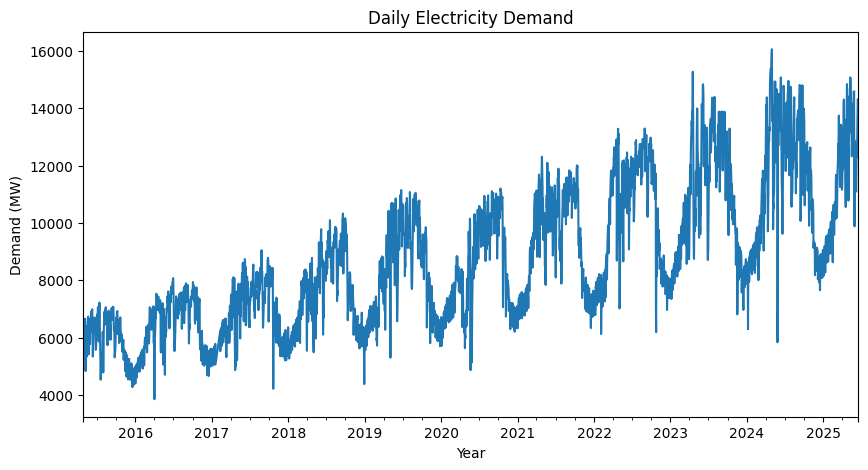

In [41]:
# Daily average demand
df_daily = df['demand_mw'].resample('D').mean().interpolate()

df_daily.plot(figsize=(10,5), title="Daily Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Demand (MW)")
plt.show()


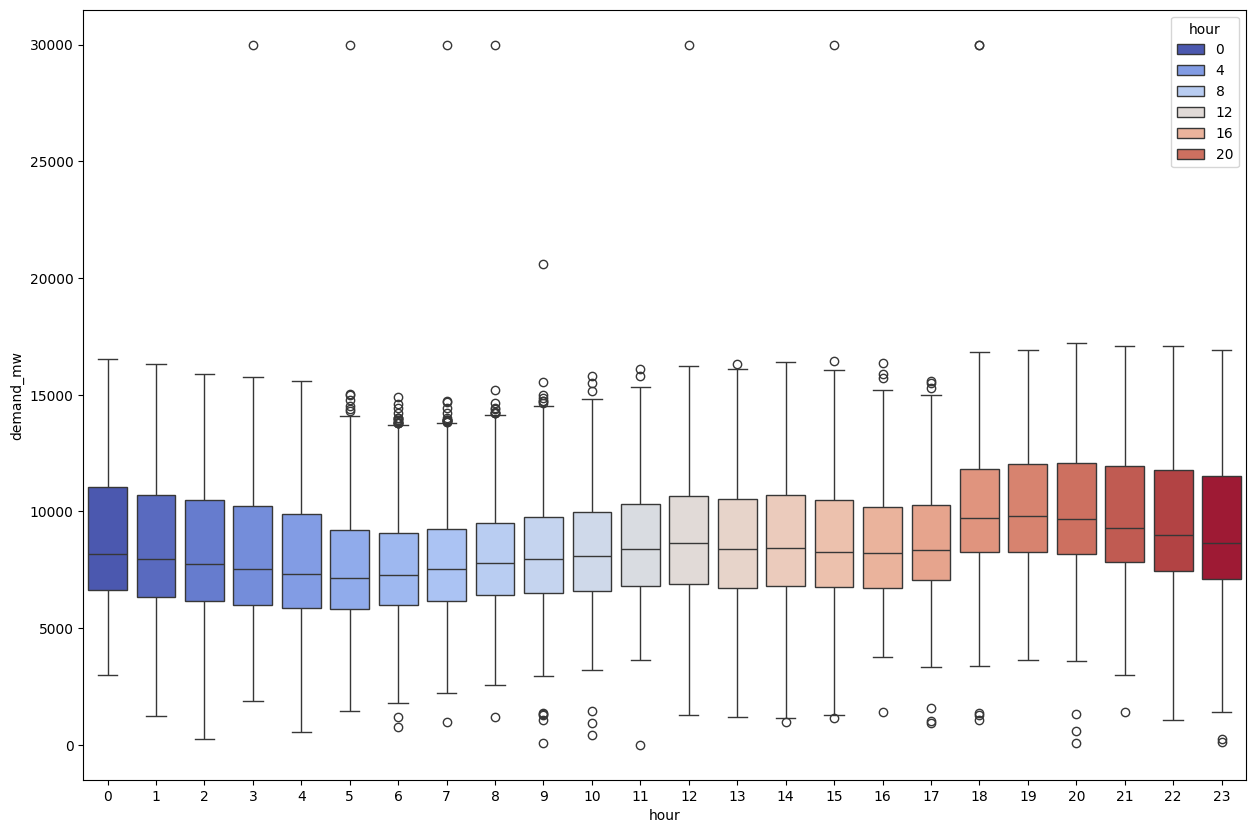

In [42]:
plt.figure(figsize=(15,10))
sns.boxplot(
    x="hour",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="hour",
    #showfliers=False
);


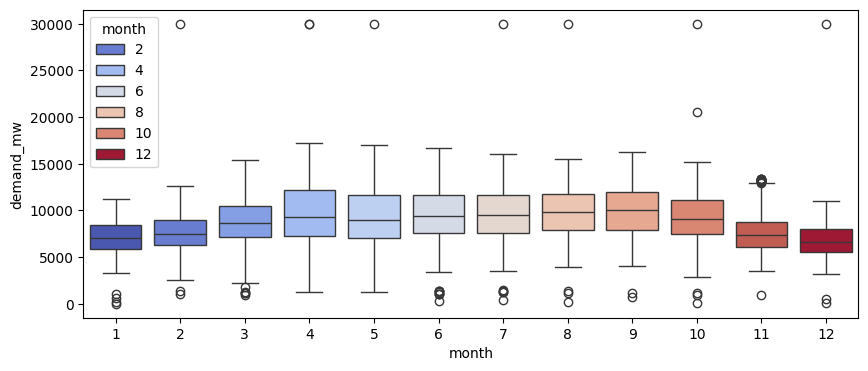

In [43]:
plt.figure(figsize=(10,4))
sns.boxplot(
    x="month",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="month",
    #showfliers=False
);


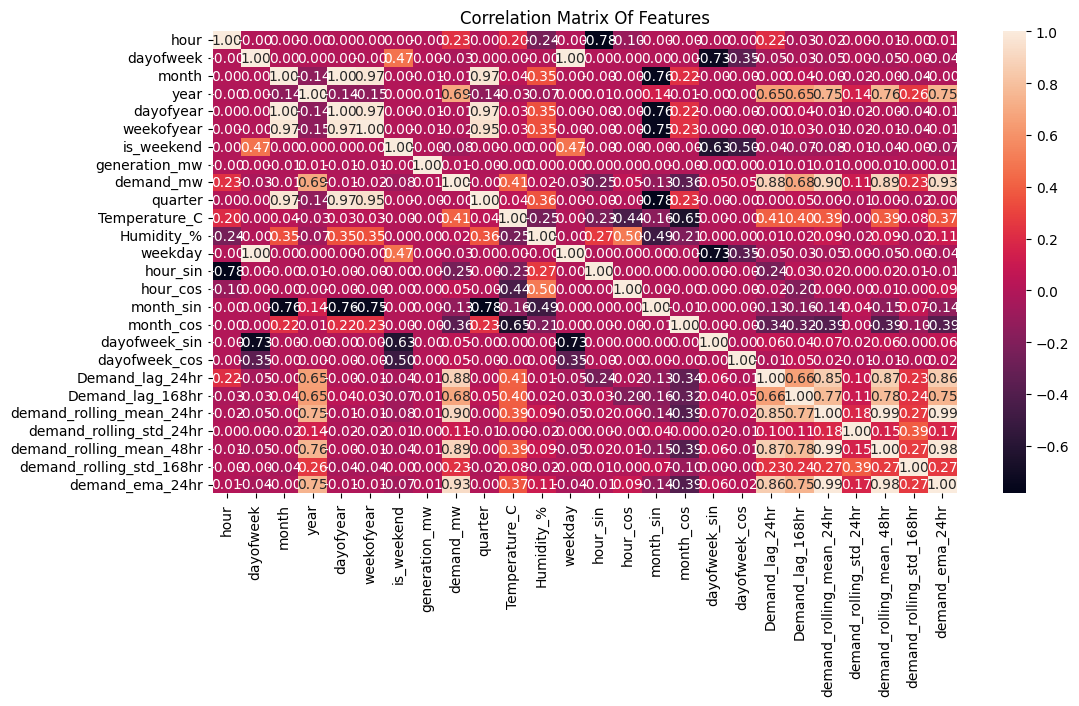

In [44]:
# correlation matrix
plt.figure(figsize=(12,6))
plt.title("Correlation Matrix Of Features")
sns.heatmap(df.corr(),annot=True,fmt=".2f");

In [45]:
#define target variable y
y=df.demand_mw # target variable/ dependent variable
print(y)

datetime
2015-04-27 08:00:00     5200
2015-04-27 09:00:00     5430
2015-04-27 10:00:00     5531
2015-04-27 11:00:00     5602
2015-04-27 12:00:00     5459
                       ...  
2025-06-17 08:00:00    11896
2025-06-17 09:00:00    12290
2025-06-17 10:00:00    12443
2025-06-17 11:00:00    12826
2025-06-17 12:00:00    13139
Name: demand_mw, Length: 92482, dtype: int64


In [46]:
#define Features(x)
x=df.drop("demand_mw",axis=1)  #indipendent variables/ features/predictors
x

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,quarter,Temperature_C,...,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr,demand_rolling_mean_48hr,demand_rolling_std_168hr,demand_ema_24hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-27 08:00:00,8,0,4,2015,117,18,0,5200.0,2,28.73,...,-0.5,0.000000,1.00000,4214.0,4821.0,5158.375000,645.172361,5069.750000,1149.617273,5011.914316
2015-04-27 09:00:00,9,0,4,2015,117,18,0,5430.0,2,30.01,...,-0.5,0.000000,1.00000,4380.0,3612.0,5202.125000,625.392559,5083.645833,1144.053650,5045.361171
2015-04-27 10:00:00,10,0,4,2015,117,18,0,5531.0,2,30.87,...,-0.5,0.000000,1.00000,4526.0,3727.0,5244.000000,611.647597,5103.187500,1139.428070,5084.212277
2015-04-27 11:00:00,11,0,4,2015,117,18,0,5602.0,2,31.46,...,-0.5,0.000000,1.00000,4653.0,3632.0,5283.541667,602.384824,5122.458333,1134.113687,5125.635295
2015-04-27 12:00:00,12,0,4,2015,117,18,0,5459.0,2,31.77,...,-0.5,0.000000,1.00000,4511.0,3641.0,5323.041667,580.197529,5121.229167,1128.432286,5152.304471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,2,28.74,...,-1.0,0.781831,0.62349,13155.0,12403.0,13804.000000,1112.699850,14023.041667,1228.948776,13479.928197
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,2,29.37,...,-1.0,0.781831,0.62349,13569.0,12072.0,13750.708333,1154.295060,13984.437500,1227.536731,13384.733941
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,2,29.77,...,-1.0,0.781831,0.62349,13816.0,11377.0,13693.500000,1184.545849,13950.562500,1219.170398,13309.395226


In [47]:
# Splitting the data into training and teating data
x_train=x.loc[ : "2023-12-31"]   #taking 80% 0f data as training data
x_train

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,quarter,Temperature_C,...,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr,demand_rolling_mean_48hr,demand_rolling_std_168hr,demand_ema_24hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-27 08:00:00,8,0,4,2015,117,18,0,5200.0,2,28.73,...,-0.5,0.000000,1.00000,4214.0,4821.0,5158.375000,645.172361,5069.750000,1149.617273,5011.914316
2015-04-27 09:00:00,9,0,4,2015,117,18,0,5430.0,2,30.01,...,-0.5,0.000000,1.00000,4380.0,3612.0,5202.125000,625.392559,5083.645833,1144.053650,5045.361171
2015-04-27 10:00:00,10,0,4,2015,117,18,0,5531.0,2,30.87,...,-0.5,0.000000,1.00000,4526.0,3727.0,5244.000000,611.647597,5103.187500,1139.428070,5084.212277
2015-04-27 11:00:00,11,0,4,2015,117,18,0,5602.0,2,31.46,...,-0.5,0.000000,1.00000,4653.0,3632.0,5283.541667,602.384824,5122.458333,1134.113687,5125.635295
2015-04-27 12:00:00,12,0,4,2015,117,18,0,5459.0,2,31.77,...,-0.5,0.000000,1.00000,4511.0,3641.0,5323.041667,580.197529,5121.229167,1128.432286,5152.304471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,19,6,12,2023,365,52,0,9894.0,4,17.86,...,1.0,-0.781831,0.62349,9993.0,7288.0,8576.541667,1094.012081,8395.895833,1100.748421,8945.023434
2023-12-31 20:00:00,20,6,12,2023,365,52,0,9669.0,4,17.15,...,1.0,-0.781831,0.62349,9706.0,6975.0,8575.000000,1092.376110,8418.541667,1098.874007,9002.941559
2023-12-31 21:00:00,21,6,12,2023,365,52,0,9250.0,4,16.60,...,1.0,-0.781831,0.62349,8625.0,6844.0,8601.041667,1101.035421,8443.750000,1093.380324,9022.706234


In [48]:
y_train=y.loc[ : "2023-12-31"]   #taking 80% 0f data as training data
y_train

,demand_mw
datetime,
2015-04-27 08:00:00,5200
2015-04-27 09:00:00,5430
2015-04-27 10:00:00,5531
2015-04-27 11:00:00,5602
2015-04-27 12:00:00,5459
...,...
2023-12-31 19:00:00,9894
2023-12-31 20:00:00,9669
2023-12-31 21:00:00,9250


In [49]:
y_test=y.loc[ "2024-01-01": ]   #taking 20% 0f data as testing data
y_test

,demand_mw
datetime,
2024-01-01 00:00:00,7580
2024-01-01 01:00:00,7259
2024-01-01 02:00:00,7010
2024-01-01 03:00:00,6733
2024-01-01 04:00:00,6598
...,...
2025-06-17 08:00:00,11896
2025-06-17 09:00:00,12290
2025-06-17 10:00:00,12443


In [50]:
x_test=x.loc[ "2024-01-01": ]   #taking 20% 0f data as testing data
x_test

,hour,dayofweek,month,year,dayofyear,weekofyear,is_weekend,generation_mw,quarter,Temperature_C,...,month_cos,dayofweek_sin,dayofweek_cos,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr,demand_rolling_mean_48hr,demand_rolling_std_168hr,demand_ema_24hr
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0,0,1,2024,1,1,0,7580.0,1,15.27,...,0.866025,0.000000,1.00000,7385.0,7313.0,8649.166667,1073.936225,8498.187500,1077.169461,8812.360752
2024-01-01 01:00:00,1,0,1,2024,1,1,0,7259.0,1,14.84,...,0.866025,0.000000,1.00000,7123.0,7982.0,8654.833333,1065.861671,8511.062500,1080.658192,8688.091892
2024-01-01 02:00:00,2,0,1,2024,1,1,0,7010.0,1,14.44,...,0.866025,0.000000,1.00000,6791.0,8527.0,8663.958333,1050.031241,8523.062500,1086.649727,8553.844541
2024-01-01 03:00:00,3,0,1,2024,1,1,0,6733.0,1,14.03,...,0.866025,0.000000,1.00000,6752.0,8375.0,8663.166667,1051.541505,8532.479167,1094.941239,8408.176977
2024-01-01 04:00:00,4,0,1,2024,1,1,0,6598.0,1,13.62,...,0.866025,0.000000,1.00000,7068.0,8536.0,8643.583333,1086.341323,8531.250000,1104.398840,8263.362819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,1,6,2025,168,25,0,11896.0,2,28.74,...,-1.000000,0.781831,0.62349,13155.0,12403.0,13804.000000,1112.699850,14023.041667,1228.948776,13479.928197
2025-06-17 09:00:00,9,1,6,2025,168,25,0,12290.0,2,29.37,...,-1.000000,0.781831,0.62349,13569.0,12072.0,13750.708333,1154.295060,13984.437500,1227.536731,13384.733941
2025-06-17 10:00:00,10,1,6,2025,168,25,0,12443.0,2,29.77,...,-1.000000,0.781831,0.62349,13816.0,11377.0,13693.500000,1184.545849,13950.562500,1219.170398,13309.395226


In [51]:
print(x_train.shape)
print(y_train.shape)

(79146, 25)
(79146,)


In [52]:
print(x_test.shape)
print(y_test.shape)

(13336, 25)
(13336,)


#Decision Tree

In [53]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
dt_model=DecisionTreeRegressor(max_depth=6,
                               min_samples_split=20,
                               min_samples_leaf=10,
                               criterion="squared_error",
                               random_state=42)
dt_model.fit(x_train,y_train)
dt_pred=dt_model.predict(x_test)
rmse_dt=np.sqrt(mean_squared_error(y_test,dt_pred))
mae_dt=mean_absolute_error(y_test,dt_pred)

print("Decision Tree RMSE: ",rmse_dt)
print("Decision Tree MAE ",mae_dt)

Decision Tree RMSE:  614.2394782202916
Decision Tree MAE  305.32218278144893


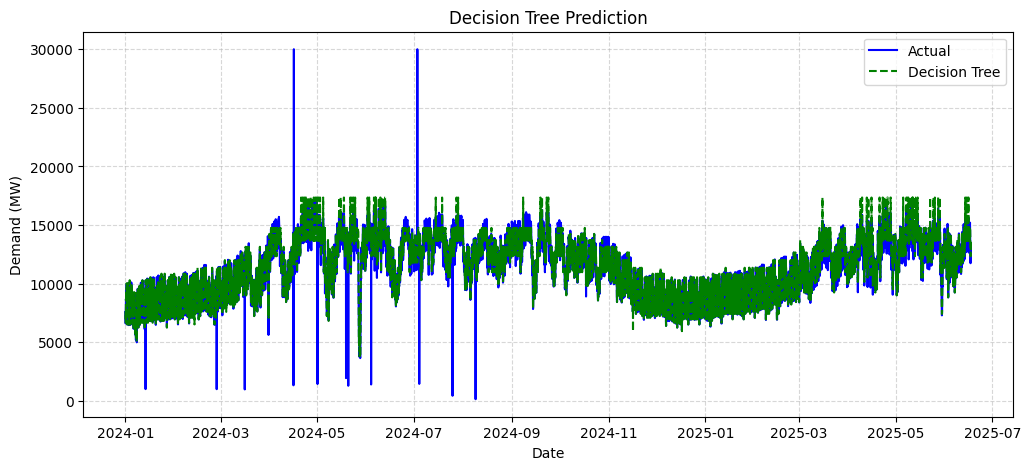

In [54]:
# Decision Tree prediction plot
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual', color='blue')           # Real demand
plt.plot(y_test.index, dt_pred, label='Decision Tree', color='green', linestyle='--')  # Predicted by Decision Tree
plt.title("Decision Tree Prediction")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#Random Forest

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
rf_model=RandomForestRegressor(n_estimators=200,
                               max_depth=8,
                               min_samples_split=5,
                               min_samples_leaf=2,
                               random_state=42)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 529.0334072715602
Random Forest MAE: 236.15597532632967


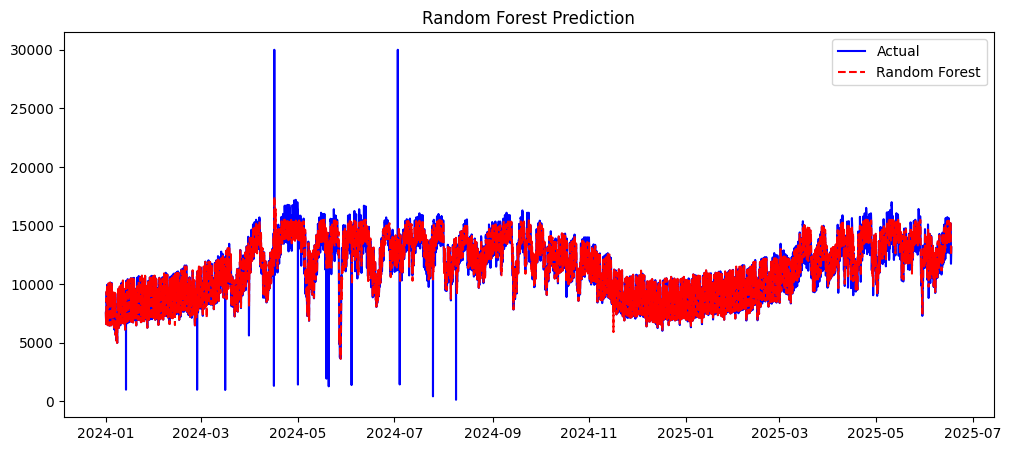

In [56]:

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, rf_pred, label='Random Forest', color='red', linestyle='--')
plt.title("Random Forest Prediction")
plt.legend()
plt.show()


#XGBoost

In [57]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [58]:
model_xgb=XGBRegressor(n_estimators=2500,
                       early_stopping_rounds=50,
                       learning_rate=0.005,
                       max_depth=7,
                       min_child_weight=3,
                       gamma=1,
                       subsample=0.8,
                       reg_alpha=0.1,
                       reg_lambda=1.5,
                       random_state=42,
                       objective="reg:squarederror")

In [59]:
model_xgb.fit(x_train,y_train,eval_set=[(x_train,y_train),(x_test,y_test)],verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.005, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2500,
             n_jobs=None, num_parallel_tree=None, ...)

In [60]:
predictions_xgb=model_xgb.predict(x_test)
rmse_xgb=np.sqrt(mean_squared_error(y_test,predictions_xgb))
mae_xgb=mean_absolute_error(y_test,predictions_xgb)
print("XGBoost RMSE:",rmse_xgb)
print("XGBoost MAE:",mae_xgb)

XGBoost RMSE: 544.193554721112
XGBoost MAE: 251.81764221191406


Text(65.84722222222221, 0.5, 'Demand')

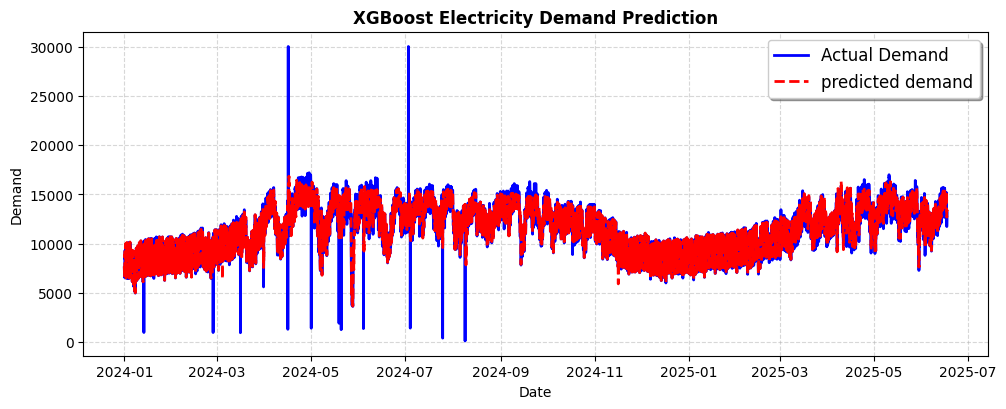

In [61]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index,y_test,label="Actual Demand",color="Blue", linewidth=2)
plt.plot(y_test.index,predictions_xgb,label="predicted demand",color='Red',linestyle="--", linewidth=2)
plt.title("XGBoost Electricity Demand Prediction",fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(fontsize=12, shadow=True)

plt.xlabel("Date")
plt.ylabel("Demand")

In [62]:
from sklearn.metrics import r2_score
r2_dt=r2_score(y_test,dt_pred)
r2_rf=r2_score(y_test,rf_pred)
r2_xgb=r2_score(y_test,predictions_xgb)

print("Decision Tree R2: ",r2_dt)
print("Random Forest R2:",r2_rf)
print("XGBoost R2: ",r2_xgb)




Decision Tree R2:  0.9335871927925878
Random Forest R2: 0.9507345355573742
XGBoost R2:  0.9478705525398254


In [63]:
# Prepare buffer for lag features
pred_buffer = list(x_test['Demand_lag_24hr'].iloc[-24:].values)  # last 24 hours
future_preds = []

# Start from last row of test set
last_row = x_test.iloc[-1:].copy()
current_time = last_row.index[0]

for i in range(24):
    # update lag features properly
    last_row['Demand_lag_24hr'] = pred_buffer[-24] if len(pred_buffer) >= 24 else pred_buffer[0]
    last_row['Demand_lag_168hr'] = pred_buffer[-168] if len(pred_buffer) >= 168 else pred_buffer[0]

    # prediction
    pred = model_xgb.predict(last_row)[0]
    future_preds.append(pred)
    pred_buffer.append(pred)

    # update time features
    current_time += pd.Timedelta(hours=1)
    last_row['hour'] = current_time.hour
    last_row['dayofweek'] = current_time.dayofweek
    last_row['month'] = current_time.month
    last_row['dayofyear'] = current_time.dayofyear
    last_row['weekofyear'] = current_time.week
    last_row['quarter'] = current_time.quarter
    last_row['weekday'] = current_time.weekday()
    last_row['is_weekend'] = int(current_time.weekday() >= 5)

    # update rolling statistics
    last_row['demand_rolling_mean_24hr'] = np.mean(pred_buffer[-24:])
    last_row['demand_rolling_std_24hr'] = np.std(pred_buffer[-24:])

# future_preds contains realistic next 24-hour forecast
print(future_preds)


[np.float32(13327.031), np.float32(13271.614), np.float32(13126.888), np.float32(13276.203), np.float32(13244.528), np.float32(13223.735), np.float32(13881.1), np.float32(13890.035), np.float32(13850.714), np.float32(13844.898), np.float32(13827.66), np.float32(13846.734), np.float32(13353.993), np.float32(13352.156), np.float32(13351.003), np.float32(13205.096), np.float32(13207.072), np.float32(13175.521), np.float32(13189.816), np.float32(13219.079), np.float32(13254.301), np.float32(13356.01), np.float32(13357.438), np.float32(13357.438)]


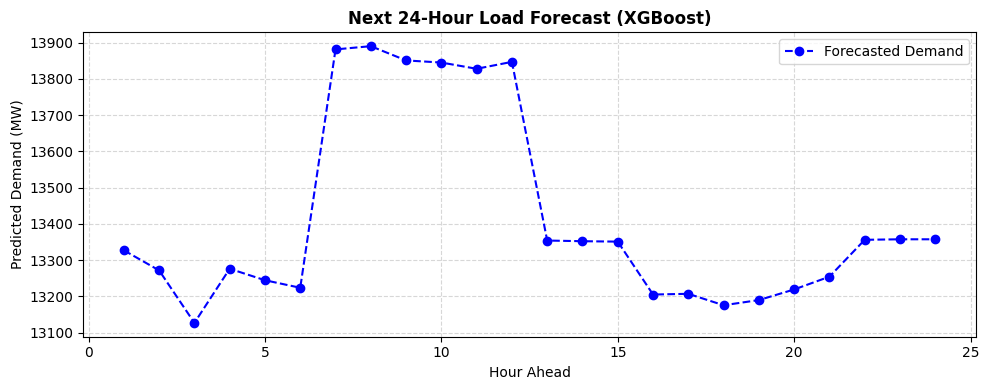

In [64]:
plt.figure(figsize=(10,4))
plt.plot(range(1,25), future_preds, marker='o', color='blue', linestyle='--', label='Forecasted Demand')
plt.title("Next 24-Hour Load Forecast (XGBoost)", fontweight='bold')
plt.xlabel("Hour Ahead")
plt.ylabel("Predicted Demand (MW)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


ANN

Scaling (MinMax)

In [65]:
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

Tensor Convert

In [66]:
import torch

x_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_t = torch.tensor(x_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

In [67]:
import torch.nn as nn
import torch.optim as optim

class ResearchANN(nn.Module):
    def __init__(self, input_size):
        super(ResearchANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

Initialize Model

In [68]:
input_size = x_train_t.shape[1]

model = ResearchANN(input_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

Training with Loss Tracking

In [69]:
epochs = 300

train_losses = []

for epoch in range(epochs):

    model.train()

    outputs = model(x_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch+1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.6f}")

Epoch [25/300] Loss: 0.016698
Epoch [50/300] Loss: 0.007488
Epoch [75/300] Loss: 0.005876
Epoch [100/300] Loss: 0.005060
Epoch [125/300] Loss: 0.004405
Epoch [150/300] Loss: 0.004008
Epoch [175/300] Loss: 0.003578
Epoch [200/300] Loss: 0.003296
Epoch [225/300] Loss: 0.003020
Epoch [250/300] Loss: 0.002776
Epoch [275/300] Loss: 0.002596
Epoch [300/300] Loss: 0.002436


Evaluation  (RMSE + MAE + MAPE + R²)

In [70]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

model.eval()

with torch.no_grad():
    predictions = model(x_test_t)

# Back to original scale
predictions = scaler_y.inverse_transform(predictions.numpy())
y_test_actual = scaler_y.inverse_transform(y_test_t.numpy())

# Metrics
rmse_ann = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae_ann = mean_absolute_error(y_test_actual, predictions)

# MAPE (manual calculation)
mape_ann = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

r2_ann = r2_score(y_test_actual, predictions)

print("Research ANN RMSE:", rmse_ann)
print("Research ANN MAE:", mae_ann)
print("Research ANN MAPE:", mape_ann)
print("Research ANN R2:", r2_ann)

Research ANN RMSE: 1130.6605370313407
Research ANN MAE: 860.6614990234375
Research ANN MAPE: 8.938251
Research ANN R2: 0.774969756603241


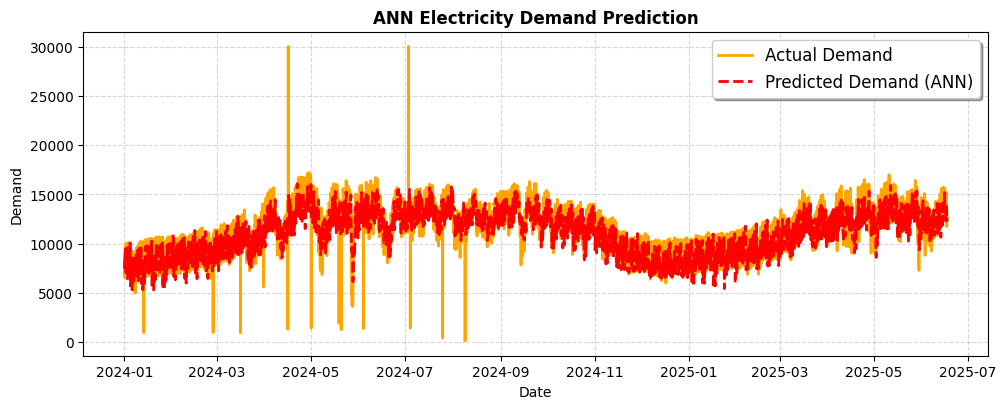

In [71]:
plt.figure(figsize=(10,4))

plt.plot(y_test.index, y_test_actual.flatten(),
         label="Actual Demand",
         color="Orange",
         linewidth=2)

plt.plot(y_test.index, predictions.flatten(),
         label="Predicted Demand (ANN)",
         color="Red",
         linestyle="--",
         linewidth=2)

plt.title("ANN Electricity Demand Prediction", fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(fontsize=12, shadow=True)

plt.xlabel("Date")
plt.ylabel("Demand")

plt.show()

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim

# =======================
# 1️⃣ LSTM Dataset Preparation
# =======================
# Function to create sequences for LSTM
def create_sequences(x, y, seq_length):
    sequences = []
    labels = []
    for i in range(len(x) - seq_length):
        sequences.append(x[i:i+seq_length])
        labels.append(y[i+seq_length])
    return torch.stack(sequences), torch.stack(labels)

seq_length = 24  # Example: 24 hours sequence
x_train_seq, y_train_seq = create_sequences(x_train_t, y_train_t, seq_length)
x_test_seq, y_test_seq = create_sequences(x_test_t, y_test_t, seq_length)

print("x_train_seq shape:", x_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

x_train_seq shape: torch.Size([79122, 24, 25])
y_train_seq shape: torch.Size([79122, 1])


In [73]:
# =======================
# 2️⃣ LSTM Model Definition
# =======================
class ResearchLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(ResearchLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)  # Output single value

    def forward(self, x):
        # LSTM output
        out, _ = self.lstm(x)
        # Take the output of the last time step
        out = out[:, -1, :]
        out = self.fc(out)
        return out

input_size = x_train_t.shape[1]
model = ResearchLSTM(input_size)

In [74]:
# =======================
# 3️⃣ Training Setup
# =======================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 300  # Example: adjust based on your dataset
batch_size = 64

# Create DataLoader
train_dataset = torch.utils.data.TensorDataset(x_train_seq, y_train_seq)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# =======================
# 4️⃣ Training Loop
# =======================
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    if (epoch+1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

Epoch [25/300], Loss: 0.000371
Epoch [50/300], Loss: 0.000347
Epoch [75/300], Loss: 0.000338
Epoch [100/300], Loss: 0.000325
Epoch [125/300], Loss: 0.000320
Epoch [150/300], Loss: 0.000320


In [ ]:

#Evaluation
model.eval()
with torch.no_grad():
    y_pred_train = model(x_train_seq)
    y_pred_test = model(x_test_seq)

# Inverse scale predictions
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test.numpy())
y_test_inv = scaler_y.inverse_transform(y_test_seq.numpy())

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv))
mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
r2 = r2_score(y_test_inv, y_pred_test_inv)

print(f"LSTM RMSE: {rmse}")
print(f"LSTM MAE: {mae}")
print(f"LSTM R2: {r2}")

In [ ]:
import matplotlib.pyplot as plt


# Prepare Data for Plotting
# Already have inverse-transformed predictions and actuals
# y_pred_test_inv, y_test_inv

plt.figure(figsize=(15,6))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(y_pred_test_inv, label='LSTM Predicted', color='red')
plt.title("LSTM Predictions vs Actual Values")
plt.xlabel("Time Steps")
plt.ylabel("Target Value")
plt.legend()
plt.show()

#GRU

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Sequence creation function
def create_sequences(x, y, seq_length):
    sequences = []
    labels = []
    for i in range(len(x) - seq_length):
        sequences.append(x[i:i+seq_length])
        labels.append(y[i+seq_length])
    return torch.stack(sequences), torch.stack(labels)

seq_length = 24  # adjust as needed
x_train_seq, y_train_seq = create_sequences(x_train_t, y_train_t, seq_length)
x_test_seq, y_test_seq = create_sequences(x_test_t, y_test_t, seq_length)

print("x_train_seq shape:", x_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

Define GRU Model

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # GRU layer
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        # Fully connected output
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)  # out: [batch, seq_len, hidden_size]
        out = out[:, -1, :]    # last time step
        out = self.fc(out)
        return out

Initialize Model, Loss, Optimizer, DataLoader

In [ ]:
input_size = x_train_t.shape[1]  # number of features
model = GRUModel(input_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

batch_size = 64
num_epochs = 100

train_dataset = torch.utils.data.TensorDataset(x_train_seq, y_train_seq)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Training Loop (GPU-ready)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

x_train_seq = x_train_seq.float().to(device)
y_train_seq = y_train_seq.float().to(device)
x_test_seq = x_test_seq.float().to(device)
y_test_seq = y_test_seq.float().to(device)

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    if (epoch+1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

Evaluation & Metrics

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test_seq)

# Inverse scaling
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test.cpu().numpy())
y_test_inv = scaler_y.inverse_transform(y_test_seq.cpu().numpy())

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv))
mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
r2 = r2_score(y_test_inv, y_pred_test_inv)

print(f"GRU RMSE: {rmse}")
print(f"GRU MAE: {mae}")
print(f"GRU R2: {r2}")

#CNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Function to create sequences
def create_sequences(x, y, seq_length):
    sequences = []
    labels = []
    for i in range(len(x) - seq_length):
        sequences.append(x[i:i+seq_length])
        labels.append(y[i+seq_length])
    return torch.stack(sequences), torch.stack(labels)

seq_length = 24  # adjust as needed
x_train_seq, y_train_seq = create_sequences(x_train_t, y_train_t, seq_length)
x_test_seq, y_test_seq = create_sequences(x_test_t, y_test_t, seq_length)

# CNN expects [batch, features, seq_len]
x_train_cnn = x_train_seq.permute(0, 2, 1)
x_test_cnn = x_test_seq.permute(0, 2, 1)

print("x_train_cnn shape:", x_train_cnn.shape)
print("y_train_seq shape:", y_train_seq.shape)

Define 1D CNN Model

In [ ]:
class CNN1D(nn.Module):
    def __init__(self, num_features):
        super(CNN1D, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2)
        )

        self.fc = nn.Linear(64, 1)  # output single value

    def forward(self, x):
        x = self.cnn(x)  # [batch, channels, seq_len]
        x = x.mean(dim=2)  # Global average pooling over seq_len
        x = self.fc(x)
        return x

Initialize Model, Loss, Optimizer

In [ ]:
num_features = x_train_cnn.shape[1]
model = CNN1D(num_features)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

batch_size = 64
num_epochs = 100

train_dataset = torch.utils.data.TensorDataset(x_train_cnn, y_train_seq)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Training Loop

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

x_train_cnn = x_train_cnn.float().to(device)
y_train_seq = y_train_seq.float().to(device)
x_test_cnn = x_test_cnn.float().to(device)
y_test_seq = y_test_seq.float().to(device)

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    if (epoch+1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

Evaluation & Metrics

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test_cnn)

# Inverse scale
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test.cpu().numpy())
y_test_inv = scaler_y.inverse_transform(y_test_seq.cpu().numpy())

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv))
mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
r2 = r2_score(y_test_inv, y_pred_test_inv)

print(f"CNN-1D RMSE: {rmse}")
print(f"CNN-1D MAE: {mae}")
print(f"CNN-1D R2: {r2}")

#CNN-LSTM Hybrid

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Sequence creation function (reuse your LSTM one)
def create_sequences(x, y, seq_length):
    sequences = []
    labels = []
    for i in range(len(x) - seq_length):
        sequences.append(x[i:i+seq_length])
        labels.append(y[i+seq_length])
    return torch.stack(sequences), torch.stack(labels)

seq_length = 24  # Adjust based on your data
x_train_seq, y_train_seq = create_sequences(x_train_t, y_train_t, seq_length)
x_test_seq, y_test_seq = create_sequences(x_test_t, y_test_t, seq_length)

# CNN-LSTM expects channels first for CNN
# [batch, seq_len, features] -> [batch, features, seq_len]
x_train_seq_cnn = x_train_seq.permute(0, 2, 1)
x_test_seq_cnn = x_test_seq.permute(0, 2, 1)

print("x_train_seq_cnn shape:", x_train_seq_cnn.shape)  # [samples, features, seq_len]

In [ ]:
class CNNLSTM(nn.Module):
    def __init__(self, num_features, hidden_size=64, lstm_layers=2):
        super(CNNLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm_layers = lstm_layers

        # 1D CNN layer
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2)
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.2
        )

        # Fully connected output
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # CNN expects [batch, channels, seq_len]
        x = self.cnn(x)  # [batch, 64, seq_len]
        x = x.permute(0, 2, 1)  # [batch, seq_len, 64] for LSTM
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # last time step
        out = self.fc(out)
        return out

num_features = x_train_seq_cnn.shape[1]
model = CNNLSTM(num_features)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 300
batch_size = 64

train_dataset = torch.utils.data.TensorDataset(x_train_seq_cnn, y_train_seq)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    if (epoch+1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test_seq_cnn)

# Inverse scale
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test.numpy())
y_test_inv = scaler_y.inverse_transform(y_test_seq.numpy())

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv))
mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
r2 = r2_score(y_test_inv, y_pred_test_inv)

print(f"CNN-LSTM RMSE: {rmse}")
print(f"CNN-LSTM MAE: {mae}")
print(f"CNN-LSTM R2: {r2}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(y_pred_test_inv, label='CNN-LSTM Predicted', color='red')
plt.title("CNN-LSTM Predictions vs Actual Values")
plt.xlabel("Time Steps")
plt.ylabel("Target Value")
plt.legend()
plt.show()

#CNN-GRU Hybrid

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Function to create sequences
def create_sequences(x, y, seq_length):
    sequences = []
    labels = []
    for i in range(len(x) - seq_length):
        sequences.append(x[i:i+seq_length])
        labels.append(y[i+seq_length])
    return torch.stack(sequences), torch.stack(labels)

seq_length = 24  # adjust as needed
x_train_seq, y_train_seq = create_sequences(x_train_t, y_train_t, seq_length)
x_test_seq, y_test_seq = create_sequences(x_test_t, y_test_t, seq_length)

# CNN expects [batch, features, seq_len]
x_train_seq_cnn = x_train_seq.permute(0, 2, 1)
x_test_seq_cnn = x_test_seq.permute(0, 2, 1)

print("x_train_seq_cnn shape:", x_train_seq_cnn.shape)
print("y_train_seq shape:", y_train_seq.shape)

CNN-GRU Model Definition

In [ ]:
class CNNGRU(nn.Module):
    def __init__(self, num_features, hidden_size=64, gru_layers=2):
        super(CNNGRU, self).__init__()
        self.hidden_size = hidden_size
        self.gru_layers = gru_layers

        # 1D CNN layers
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2)
        )

        # GRU layer
        self.gru = nn.GRU(
            input_size=64,
            hidden_size=hidden_size,
            num_layers=gru_layers,
            batch_first=True,
            dropout=0.2
        )

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # CNN expects [batch, channels, seq_len]
        x = self.cnn(x)          # [batch, 64, seq_len]
        x = x.permute(0, 2, 1)   # [batch, seq_len, 64] for GRU
        out, _ = self.gru(x)
        out = out[:, -1, :]      # last time step
        out = self.fc(out)
        return out

Model, Loss, Optimizer, DataLoader

In [ ]:
num_features = x_train_seq_cnn.shape[1]
model = CNNGRU(num_features)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 300
batch_size = 64

train_dataset = torch.utils.data.TensorDataset(x_train_seq_cnn, y_train_seq)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Training Loop

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

x_train_seq_cnn = x_train_seq_cnn.float().to(device)
y_train_seq = y_train_seq.float().to(device)
x_test_seq_cnn = x_test_seq_cnn.float().to(device)
y_test_seq = y_test_seq.float().to(device)

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    if (epoch+1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

Evaluation & Metrics

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test_seq_cnn)

# Inverse scale
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test.cpu().numpy())
y_test_inv = scaler_y.inverse_transform(y_test_seq.cpu().numpy())

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_test_inv))
mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
r2 = r2_score(y_test_inv, y_pred_test_inv)

print(f"CNN-GRU RMSE: {rmse}")
print(f"CNN-GRU MAE: {mae}")
print(f"CNN-GRU R2: {r2}")